In [6]:
#-----------------------------
# Packages Import
#-----------------------------
%matplotlib inline


import numpy as np
from matplotlib import pyplot as plt

# Used to handle picture drawings
import cv2

# Used Handle directories and paths
import os

# Used to create and compute random angles
import random
import math

# Used to create the image labels
import json



In [11]:
#--------------------------
# Constants across the project
#----------------------------

# Mapping cardinal directions to approximate angles (in radians)
# Starting N at -90 degrees (standard Cartesian setup in image space)
DIRECTIONS = {
    "N":  -math.pi/2, "NE": -math.pi/4, "E": 0, "SE": math.pi/4,
    "S":   math.pi/2, "SW": 3*math.pi/4, "W": math.pi, "NW": -3*math.pi/4
}

DIRECTIONS_NUMBER= {
    "N":  1, "NE": 2, "E": 3, "SE": 4,
    "S":   5, "SW": 6, "W": 7, "NW": 8
}


DIR_KEYS = list(DIRECTIONS.keys())


In [12]:
#------------------------
#Basic Drawing functions:
#-----------------------

def get_boundary_point(angle, size):
    """Calculates where a line at 'angle' hits the image boundary."""
    h, w = size
    cx, cy = w // 2, h // 2
    
    # Large distance to ensure we hit the boundary
    dist = max(w, h)
    
    x1 = int(cx - dist * math.cos(angle))
    y1 = int(cy - dist * math.sin(angle))
    x2 = int(cx + dist * math.cos(angle))
    y2 = int(cy + dist * math.sin(angle))
    
    _,p1,p2 = cv2.clipLine((0, 0, w, h), (x1, y1), (x2, y2))
    return [p1,p2] 


#This function Draws a line going through the center given the angle
def draw_strand(img, angle, thickness, isMain):
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    
    p_in, p_out= get_boundary_point(angle, (h, w))
    
    cv2.line(img, p_in, p_out, (0,255,0), thickness, cv2.LINE_AA)
    if isMain: cv2.circle(img,p_in, 10, (0,255,0), -1)
    
    return None

#This function Draws an overline line going through the center given the angle
def draw_over_strand(img, angle, thickness, isMain):
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    
    p_in, p_out= get_boundary_point(angle, (h, w))
    
    cv2.line(img, p_in, p_out, (255,255,255), thickness+4, cv2.LINE_AA)
    cv2.line(img, p_in, p_out, (0,255,0), thickness, cv2.LINE_AA)
    if isMain: cv2.circle(img,p_in, 10, (0,255,0), -1)
    return None


In [13]:
#------------------
# Advanced drawing functions
#------------------


#------------------
# Constants
#----------------------
WINDOW_SIZE = (64, 64) 
THICKNESS = 2


#--------------------------------------------
# Drawing functions
#-----------------------------------------
def draw_Straight_Line(direction):
    #Randomize the main direction
    angle = DIRECTIONS[DIR_KEYS[direction]]+ random.uniform(-1, 1)*math.pi/16
    draw_strand(img, angle, THICKNESS  * 2, True)
    return None


def draw_over_crossing(direction1, direction2):

    #Randomize a small tilt of the main picture
    angle1 = DIRECTIONS[DIR_KEYS[(direction1 + 2) % 8]]+ random.uniform(-1, 1)*math.pi/16
    angle2 = DIRECTIONS[DIR_KEYS[(direction2 + 2) % 8]]+ random.uniform(-1, 1)*math.pi/16

    # Draw secondary strand FIRST (it goes underneath)
    draw_strand(img, angle2, THICKNESS  * 2, False)
    # Draw primary strand SECOND (it goes on top)
    draw_over_strand(img, angle1, THICKNESS  * 2, True)

    return None


def draw_under_crossing(direction1, direction2):
        #Randomize a small tilt of the main picture
    angle1 = DIRECTIONS[DIR_KEYS[(direction1 + 2) % 8]]+ random.uniform(-1, 1)*math.pi/16
    angle2 = DIRECTIONS[DIR_KEYS[(direction2 + 2) % 8]]+ random.uniform(-1, 1)*math.pi/16

    # Draw primary strand FIRST (it goes underneath)
    draw_strand(img, angle1, THICKNESS  * 2, True)
    # Draw secondart strand SECOND (it goes on top)
    draw_over_strand(img, angle2, THICKNESS  * 2, False)

    return None

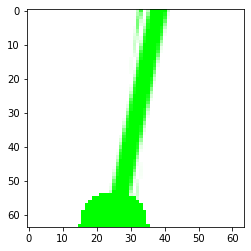

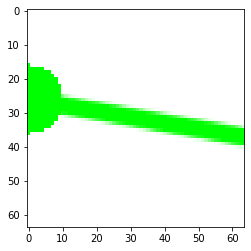

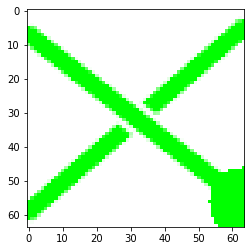

In [14]:
#-------------------------------
# Small cell that generates 5 random corssing
#-------------------------------

N=3

for i in range(N):
    # Initialize a clean, gray background
    img = np.full((WINDOW_SIZE[1], WINDOW_SIZE[0], 3), -1, dtype=np.uint8)
    
    
    # 2. Randomize the crossing type (33% No, 33% Over, 33% Under)
    cross_choice = random.random()
    main_direction, other_direction = random.sample(range(1, 7), 2)
    
    if cross_choice < 0.33:
        # State: NONE
        crossing_type = "None"
        draw_Straight_Line(main_direction) 
            
    elif cross_choice >= 0.33 and cross_choice < 0.66:
        # State: OVER-CROSSING
        crossing_type = "Over"
        draw_over_crossing(main_direction, other_direction)  
    
    else:
        # State: UNDER-CROSSING
        crossing_type = "Under"
        draw_under_crossing(main_direction, other_direction)

    plt.imshow(img)
    plt.show()
    

In [15]:
#-------------------------------------
# Image creation loop
#--------------------------------------


OUTPUT_DIR = "local_Knot_training_data"
NUM_IMAGES = 100 # Start with this to test



# current working directory
path = os.getcwd()
# data directory
DATA_DIR = os.path.join(path, os.pardir,'data',OUTPUT_DIR)

# Ensure output directory exists
os.makedirs( DATA_DIR, exist_ok=True)
#os.makedirs(os.path.join(data_, "images"), exist_ok=True)

dataset_labels = []

for i in range(NUM_IMAGES):
    # Initialize a clean, gray background
    img = np.full((WINDOW_SIZE[1], WINDOW_SIZE[0], 3), -1, dtype=np.uint8)
    
    
    # 2. Randomize the crossing type (33% No, 33% Over, 33% Under)
    cross_choice = random.random()
    main_direction, other_direction = random.sample(range(1, 7), 2)
    
    if cross_choice < 0.33:
        # State: NONE
        crossing_type = "None"
        draw_Straight_Line(main_direction) 
            
    elif cross_choice >= 0.33 and cross_choice < 0.66:
        # State: OVER-CROSSING
        crossing_type = "Over"
        draw_over_crossing(main_direction, other_direction)  
    
    else:
        # State: UNDER-CROSSING
        crossing_type = "Under"
        draw_under_crossing(main_direction, other_direction)
    
    
    #Save Image and Metadata
    img_filename = f"knot_{i:05d}.jpg"
    img_path = os.path.join(DATA_DIR, img_filename)
    cv2.imwrite(img_path, img)
    
    dataset_labels.append({
        "filename": img_filename,
        "label_index": i,
        "direction": DIR_KEYS[main_direction],
        "crossing": crossing_type,
    })
    

# Save labels to JSON
with open(os.path.join(DATA_DIR, "labels.json"), "w") as f:
    json.dump(dataset_labels, f, indent=4)

print(f"Generated {NUM_IMAGES} synthetic images in '{OUTPUT_DIR}'")

Generated 100 synthetic images in 'local_Knot_training_data'


In [ ]:
'''General comments about the image creation. So it created only straigh lines, although close enough all lineas are roughly
straigt, it would be nice to add a functionality of the code that randimly twist and curves the generated lines.'''